In [30]:
!pip -q install scikit-learn matplotlib

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_breast_cancer

%matplotlib inline
np.random.seed(42)

# TP3 — Breast Cancer MLP from Scratch

## Scope and key decisions
- 100% NumPy MLP with manual forward pass, backpropagation, and mini-batch gradient descent.
- ReLU in hidden layers and Softmax at the output layer (assignment requirement).
- Mean cross-entropy loss computed per mini-batch.
- Z-score standardization uses **only training** mean/std (no data leakage).
- Stratified 80/20 train/test split preserves class proportions.
- Test set is reused during hyperparameter search for simplicity; the final model is retrained with the best settings found.

## Notebook outline
1. **Data Processing** — load, split, standardize
2. **Model Implementation** — activations, loss, MLP class
3. **Training and Visualization** — baseline run, loss/accuracy curves
4. **Parameter Exploration** — learning rate, batch size, architecture
5. **Final Test** — retrain best config, report metrics
6. **Interpretability** — input gradients, ablation, individual explanations

## 1. Data Processing

### 1.1 Load dataset

- **Source:** Breast Cancer Wisconsin (Diagnostic), via `sklearn.datasets.load_breast_cancer`.
- **Features:** 30 numeric measurements per tumor.
- **Labels:** mapped to 0 = benign (B), 1 = malignant (M). sklearn uses the opposite encoding, so we flip it.

In [32]:
# Breast Cancer Wisconsin (Diagnostic) — UCI dataset bundled in scikit-learn.
bc = load_breast_cancer()
X_df = pd.DataFrame(bc.data, columns=bc.feature_names)
X = X_df.values.astype(np.float64)
# sklearn: 0=malignant, 1=benign → notebook labels: M=1, B=0
y_labels = (1 - bc.target).astype(int)
feature_names = bc.feature_names.tolist()

print("X shape:", X.shape)
print("y shape:", y_labels.shape)
print("Class counts:", np.bincount(y_labels))

X shape: (569, 30)
y shape: (569,)
Class counts: [357 212]


In [33]:
X_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 1.2 Preprocessing helpers

Utility functions for stratified splitting, per-feature z-score standardization (train stats only), one-hot encoding, and accuracy.

In [34]:
def stratified_split(X, y, test_size=0.2, seed=42):
    """Stratified split to preserve class proportions in train/test."""
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    train_idx = []
    test_idx = []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n_test = int(np.ceil(test_size * len(cls_idx)))
        test_idx.append(cls_idx[:n_test])
        train_idx.append(cls_idx[n_test:])
    train_idx = np.concatenate(train_idx)
    test_idx = np.concatenate(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardize_train_test(X_train, X_test):
    """Standardize using train mean/std to avoid leakage."""
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std

def one_hot(y, num_classes):
    """Convert integer labels to one-hot (num_classes)."""
    y = y.astype(int)
    out = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    out[np.arange(y.shape[0]), y] = 1.0
    return out

def accuracy(y_true, y_pred):
    """Simple accuracy: fraction of correct predictions."""
    return np.mean(y_true == y_pred)

### 1.3 Split and standardize

- Stratified 80/20 split keeps class proportions in train and test.
- Z-score uses **per-feature** train mean/std, then applied to test (no leakage).
- Labels are one-hot encoded for Softmax + cross-entropy training.

In [35]:
X_train, X_test, y_train, y_test = stratified_split(X, y_labels, test_size=0.2, seed=42)
X_train_std, X_test_std, train_mean, train_std = standardize_train_test(X_train, X_test)

num_classes = 2
y_train_oh = one_hot(y_train, num_classes)
y_test_oh = one_hot(y_test, num_classes)

print("Train shape:", X_train_std.shape, y_train_oh.shape)
print("Test shape:", X_test_std.shape, y_test_oh.shape)

Train shape: (454, 30) (454, 2)
Test shape: (115, 30) (115, 2)


## 2. Model Implementation

### 2.1 Activations and loss function

- **ReLU** in hidden layers with analytic derivative for backprop.
- **Softmax** at the output layer (numerically stable via max subtraction).
- **Cross-entropy** averaged over the mini-batch.

In [36]:
def relu(z):
    """Element-wise ReLU."""
    return np.maximum(0.0, z)

def relu_backward(dA, z):
    """ReLU gradient using pre-activation `z`."""
    dZ = dA.copy()
    dZ[z <= 0] = 0.0
    return dZ

def softmax(z):
    """Row-wise stable Softmax (subtract max to avoid overflow)."""
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(probs, y_true):
    """Mean cross-entropy over the batch."""
    eps = 1e-12
    return -np.mean(np.sum(y_true * np.log(probs + eps), axis=1))

### 2.2 MLP class

Fully-connected network with manual forward pass, backpropagation, and mini-batch gradient descent. The `input_gradient` method (Section 6) computes how each input feature affects the predicted class probability.

In [37]:
class MLP:
    """MLP with ReLU hidden layers and Softmax output."""

    def __init__(self, layer_sizes, seed=42):
        """Initialize small random weights and zero biases."""
        self.rng = np.random.default_rng(seed)
        self.W = []
        self.b = []
        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]
            W = self.rng.normal(0.0, 0.01, size=(in_dim, out_dim))
            b = np.zeros((1, out_dim), dtype=np.float64)
            self.W.append(W)
            self.b.append(b)

    def forward(self, X):
        """Forward pass; caches intermediate values for backprop."""
        A = X
        caches = []
        for i in range(len(self.W) - 1):
            Z = A @ self.W[i] + self.b[i]
            caches.append({"A_prev": A, "Z": Z})
            A = relu(Z)
        ZL = A @ self.W[-1] + self.b[-1]
        caches.append({"A_prev": A, "Z": ZL})
        probs = softmax(ZL)
        return probs, caches

    def backward(self, probs, Y, caches):
        """Backpropagation via the chain rule (Softmax + cross-entropy gradient)."""
        m = Y.shape[0]
        dZ = (probs - Y) / m
        grads_W = []
        grads_b = []
        for i in reversed(range(len(self.W))):
            A_prev = caches[i]["A_prev"]
            dW = A_prev.T @ dZ
            db = np.sum(dZ, axis=0, keepdims=True)
            grads_W.insert(0, dW)
            grads_b.insert(0, db)
            if i > 0:
                dA_prev = dZ @ self.W[i].T
                Z_prev = caches[i - 1]["Z"]
                dZ = relu_backward(dA_prev, Z_prev)
        self.grads_W = grads_W
        self.grads_b = grads_b

    def update(self, lr):
        """Plain gradient descent weight update."""
        for i in range(len(self.W)):
            self.W[i] -= lr * self.grads_W[i]
            self.b[i] -= lr * self.grads_b[i]

    def predict_proba(self, X):
        """Return Softmax class probabilities."""
        probs, _ = self.forward(X)
        return probs

    def predict(self, X):
        """Return predicted class labels (argmax)."""
        return np.argmax(self.predict_proba(X), axis=1)

    def fit(self, X_train, y_train_oh, y_train_labels, X_test, y_test_labels,
            epochs, batch_size, lr, verbose=False):
        """Mini-batch training; logs mean train loss and accuracy each epoch."""
        n = X_train.shape[0]
        history = {"train_loss": [], "train_acc": [], "test_acc": []}
        for epoch in range(epochs):
            epoch_losses = []
            indices = self.rng.permutation(n)
            for start in range(0, n, batch_size):
                batch_idx = indices[start:start + batch_size]
                Xb = X_train[batch_idx]
                yb = y_train_oh[batch_idx]
                probs, caches = self.forward(Xb)
                epoch_losses.append(cross_entropy(probs, yb))
                self.backward(probs, yb, caches)
                self.update(lr)
            history["train_loss"].append(float(np.mean(epoch_losses)))
            train_acc = accuracy(y_train_labels, self.predict(X_train))
            test_acc = accuracy(y_test_labels, self.predict(X_test))
            history["train_acc"].append(train_acc)
            history["test_acc"].append(test_acc)
            if verbose and (epoch + 1) % max(1, epochs // 5) == 0:
                print(
                    f"Epoch {epoch + 1:4d}/{epochs} | "
                    f"loss={history['train_loss'][-1]:.4f} | "
                    f"train_acc={train_acc:.3f} | test_acc={test_acc:.3f}"
                )
        return history

    def input_gradient(self, x, class_idx):
        """Gradient of P(class_idx) w.r.t. input features (for interpretability)."""
        x = x.reshape(1, -1)
        probs, caches = self.forward(x)
        p = probs[0]
        e = np.zeros_like(p)
        e[class_idx] = 1.0
        dZ = (p[class_idx] * (e - p)).reshape(1, -1)
        dA_prev = dZ @ self.W[-1].T
        for i in reversed(range(len(self.W) - 1)):
            Z = caches[i]["Z"]
            dZ = relu_backward(dA_prev, Z)
            dA_prev = dZ @ self.W[i].T
        return dA_prev.reshape(-1), probs

## 3. Training and Visualization

Train a baseline model and plot **training loss** and **train/test accuracy** curves (assignment requirement).

Default hyperparameters below; Section 4 explores alternatives.

Epoch   30/150 | loss=0.0434 | train_acc=0.989 | test_acc=0.965
Epoch   60/150 | loss=0.0329 | train_acc=0.993 | test_acc=0.957
Epoch   90/150 | loss=0.0236 | train_acc=0.993 | test_acc=0.965
Epoch  120/150 | loss=0.0188 | train_acc=0.993 | test_acc=0.965
Epoch  150/150 | loss=0.0133 | train_acc=0.998 | test_acc=0.965

Baseline final — train acc: 0.998 | test acc: 0.965


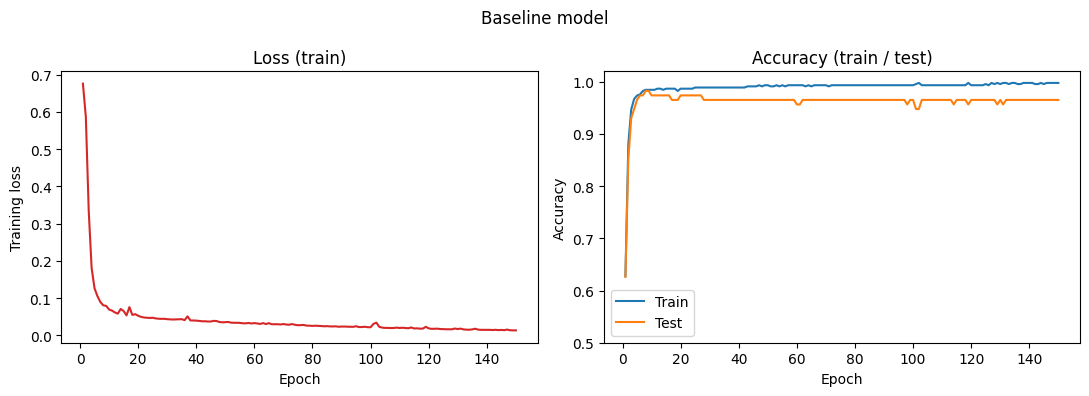

In [38]:
def plot_training_history(history, title=""):
    """Plot training loss and train/test accuracy curves."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, history["train_loss"], color="tab:red")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Training loss")
    axes[0].set_title("Loss (train)")

    axes[1].plot(epochs, history["train_acc"], label="Train", color="tab:blue")
    axes[1].plot(epochs, history["test_acc"], label="Test", color="tab:orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend()
    axes[1].set_title("Accuracy (train / test)")

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def run_training(layer_sizes, lr, batch_size, epochs, seed=42, verbose=False):
    """Train a fresh model and return it with its history."""
    model = MLP(layer_sizes, seed=seed)
    history = model.fit(
        X_train_std, y_train_oh, y_train,
        X_test_std, y_test,
        epochs=epochs, batch_size=batch_size, lr=lr, verbose=verbose,
    )
    return model, history


# Baseline configuration
BASE_ARCH = [30, 32, 2]
BASE_LR = 0.1
BASE_BATCH = 32
BASE_EPOCHS = 150

baseline_model, baseline_history = run_training(
    BASE_ARCH, BASE_LR, BASE_BATCH, BASE_EPOCHS, verbose=True
)
print(
    f"\nBaseline final — train acc: {baseline_history['train_acc'][-1]:.3f} | "
    f"test acc: {baseline_history['test_acc'][-1]:.3f}"
)
plot_training_history(baseline_history, title="Baseline model")

## 4. Parameter Exploration

We vary one hyperparameter at a time (keeping the others at baseline values) and pick the best setting by **final test accuracy**. Each experiment trains a fresh model from scratch.

| Experiment | Values tested | Fixed params |
|------------|---------------|--------------|
| Learning rate | 0.001, 0.01, 0.1 | arch=`[30,32,2]`, batch=32 |
| Batch size | 8, 32, 64 | best lr, arch=`[30,32,2]` |
| Architecture | `[30,16,2]`, `[30,32,2]`, `[30,64,32,2]` | best lr, best batch |

In [39]:
SEARCH_EPOCHS = 100  # fewer epochs for faster comparison


def compare_setting(name, values, train_fn):
    """Run experiments and return a summary table as a DataFrame."""
    rows = []
    for value in values:
        _, history = train_fn(value)
        rows.append({
            "setting": name,
            "value": value,
            "final_train_acc": history["train_acc"][-1],
            "final_test_acc": history["test_acc"][-1],
            "final_loss": history["train_loss"][-1],
        })
    return pd.DataFrame(rows)


# --- 4.1 Learning rate ---
lr_results = compare_setting(
    "learning_rate",
    [0.001, 0.01, 0.1],
    lambda lr: run_training(BASE_ARCH, lr, BASE_BATCH, SEARCH_EPOCHS),
)
best_lr = lr_results.loc[lr_results["final_test_acc"].idxmax(), "value"]
print("4.1 Learning rate")
display(lr_results.round(4))

# --- 4.2 Batch size ---
batch_results = compare_setting(
    "batch_size",
    [8, 32, 64],
    lambda bs: run_training(BASE_ARCH, best_lr, bs, SEARCH_EPOCHS),
)
best_batch = int(batch_results.loc[batch_results["final_test_acc"].idxmax(), "value"])
print(f"\n4.2 Batch size (lr={best_lr})")
display(batch_results.round(4))

# --- 4.3 Architecture ---
architectures = [[30, 16, 2], [30, 32, 2], [30, 64, 32, 2]]
arch_results = compare_setting(
    "architecture",
    architectures,
    lambda arch: run_training(arch, best_lr, best_batch, SEARCH_EPOCHS),
)
best_arch = arch_results.loc[arch_results["final_test_acc"].idxmax(), "value"]
print(f"\n4.3 Architecture (lr={best_lr}, batch={best_batch})")
display(arch_results.assign(value=arch_results["value"].astype(str)).round(4))

print(f"\nBest config: arch={best_arch}, lr={best_lr}, batch={best_batch}")
print(
    "Note: the deeper network [30, 64, 32, 2] underperforms here — "
    "likely needs more epochs or a lower learning rate."
)

4.1 Learning rate


,setting,value,final_train_acc,final_test_acc,final_loss
0,learning_rate,0.001,0.6278,0.6261,0.6472
1,learning_rate,0.010,0.9868,0.9739,0.0646
2,learning_rate,0.100,0.9934,0.9652,0.0216



4.2 Batch size (lr=0.01)


,setting,value,final_train_acc,final_test_acc,final_loss
0,batch_size,8,0.9890,0.9652,0.0410
1,batch_size,32,0.9868,0.9739,0.0646
2,batch_size,64,0.9736,0.9739,0.1026



4.3 Architecture (lr=0.01, batch=32)


,setting,value,final_train_acc,final_test_acc,final_loss
0,architecture,"[30, 16, 2]",0.9846,0.9739,0.0656
1,architecture,"[30, 32, 2]",0.9868,0.9739,0.0646
2,architecture,"[30, 64, 32, 2]",0.6278,0.6261,0.6514



Best config: arch=[30, 16, 2], lr=0.01, batch=32
Note: the deeper network [30, 64, 32, 2] underperforms here — likely needs more epochs or a lower learning rate.


## 5. Final Test

Retrain the model with the best hyperparameters found in Section 4 and report final metrics on the held-out test set.

Epoch   40/200 | loss=0.1702 | train_acc=0.963 | test_acc=0.930
Epoch   80/200 | loss=0.0777 | train_acc=0.985 | test_acc=0.983
Epoch  120/200 | loss=0.0592 | train_acc=0.987 | test_acc=0.974
Epoch  160/200 | loss=0.0550 | train_acc=0.987 | test_acc=0.974
Epoch  200/200 | loss=0.0504 | train_acc=0.987 | test_acc=0.974


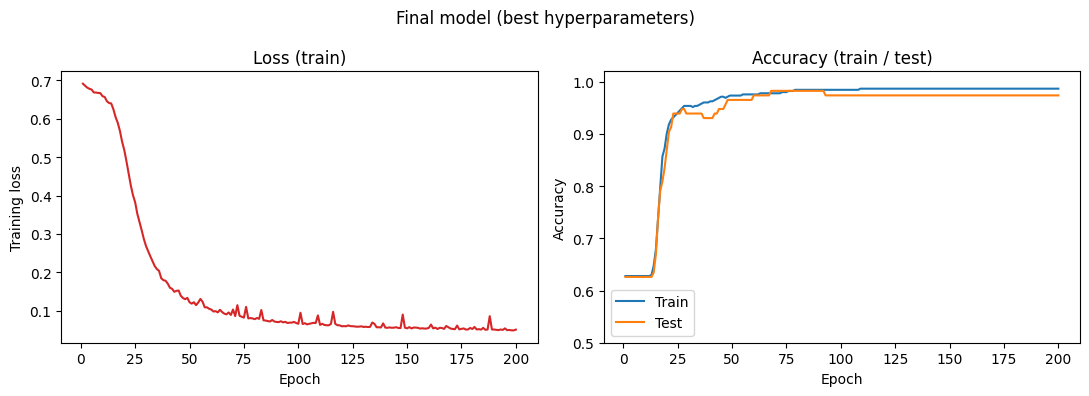


Final test accuracy: 0.974
Confusion matrix (rows=true, cols=predicted):
        pred B  pred M
true B      70       2
true M       1      42


In [40]:
FINAL_EPOCHS = 200

final_model, final_history = run_training(
    best_arch, best_lr, best_batch, FINAL_EPOCHS, verbose=True
)
plot_training_history(final_history, title="Final model (best hyperparameters)")

y_pred_test = final_model.predict(X_test_std)
test_acc = accuracy(y_test, y_pred_test)

# Confusion matrix: rows=true, cols=predicted
confusion = np.zeros((2, 2), dtype=int)
for t, p in zip(y_test, y_pred_test):
    confusion[t, p] += 1

print(f"\nFinal test accuracy: {test_acc:.3f}")
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion, index=["true B", "true M"], columns=["pred B", "pred M"]))

## 6. Interpretability

The assignment requires explaining **which inputs influence decisions** and **why specific predictions were made**. We use three complementary techniques on the final model:

1. **Input gradients** — sensitivity of the predicted class probability to each feature.
2. **Feature ablation** — zero out one feature at a time (set to train mean → 0 after standardization) and measure accuracy drop.
3. **Individual explanations** — top contributing features for selected test samples.

### 6.1 Global feature importance (input gradients)

For each test sample, compute the gradient of **P(predicted class)** w.r.t. the input features. Large absolute values mean the feature strongly affects the model's confidence for that prediction. We average |gradient| across all test samples.

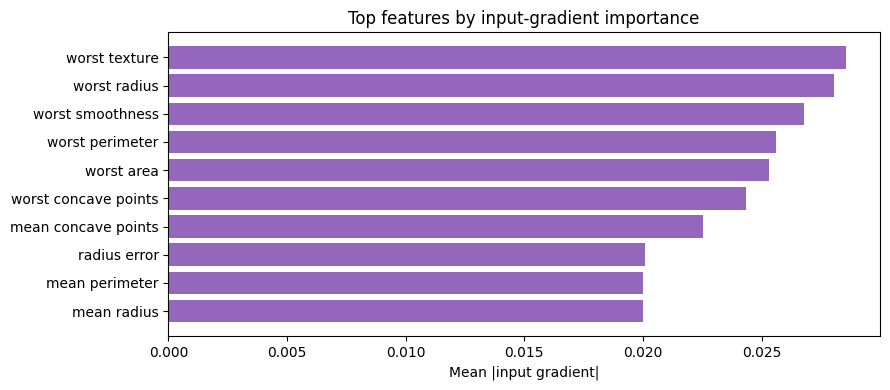

In [42]:
def global_input_importance(model, X, y_true):
    """Mean absolute input gradient w.r.t. the predicted class."""
    importances = np.zeros(X.shape[1])
    for i in range(X.shape[0]):
        pred_class = model.predict(X[i:i + 1])[0]
        grad, _ = model.input_gradient(X[i], pred_class)
        importances += np.abs(grad)
    return importances / X.shape[0]


grad_importance = global_input_importance(final_model, X_test_std, y_test)
top_k = 10
top_idx = np.argsort(grad_importance)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    grad_importance[top_idx[::-1]],
    color="tab:purple",
)
ax.set_xlabel("Mean |input gradient|")
ax.set_title("Top features by input-gradient importance")
plt.tight_layout()
plt.show()

### 6.2 Feature ablation

To validate gradient-based importance, we **ablate** each feature: replace it with 0 (the standardized train mean) on the test set and measure how much accuracy drops. A larger drop means the feature is more critical for classification.

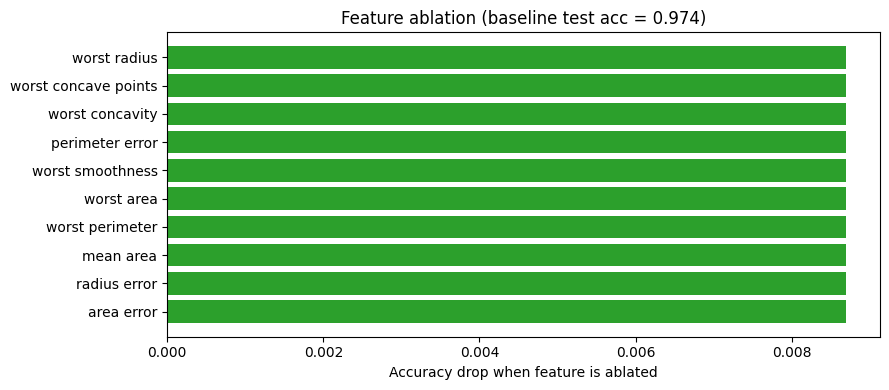

In [43]:
baseline_test_acc = accuracy(y_test, final_model.predict(X_test_std))
ablation_drops = []

for j in range(X_test_std.shape[1]):
    X_ablated = X_test_std.copy()
    X_ablated[:, j] = 0.0  # standardized train mean
    ablated_acc = accuracy(y_test, final_model.predict(X_ablated))
    ablation_drops.append(baseline_test_acc - ablated_acc)

ablation_drops = np.array(ablation_drops)
top_ablation_idx = np.argsort(ablation_drops)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    [feature_names[i] for i in top_ablation_idx[::-1]],
    ablation_drops[top_ablation_idx[::-1]],
    color="tab:green",
)
ax.set_xlabel("Accuracy drop when feature is ablated")
ax.set_title(f"Feature ablation (baseline test acc = {baseline_test_acc:.3f})")
plt.tight_layout()
plt.show()

### 6.3 Individual decision explanations

We pick three test samples — one correct benign, one correct malignant, and one misclassified — and list the top features pushing the model toward its predicted class (via signed input gradients).

In [44]:
CLASS_NAMES = {0: "benign (B)", 1: "malignant (M)"}


def explain_sample(model, x, true_label, sample_idx, top_n=5):
    """Print local explanation for a single test sample."""
    pred = model.predict(x.reshape(1, -1))[0]
    probs = model.predict_proba(x.reshape(1, -1))[0]
    grad, _ = model.input_gradient(x, pred)

    status = "CORRECT" if pred == true_label else "WRONG"
    print(f"--- Sample #{sample_idx} [{status}] ---")
    print(f"True label:      {CLASS_NAMES[true_label]}")
    print(f"Predicted label: {CLASS_NAMES[pred]}  (P={probs[pred]:.3f})")
    print("Top features by |dP/dx| (sensitivity w.r.t. predicted class):")
    top_idx = np.argsort(np.abs(grad))[::-1][:top_n]
    for rank, j in enumerate(top_idx, 1):
        effect = "increasing x raises P" if grad[j] > 0 else "increasing x lowers P"
        print(
            f"  {rank}. {feature_names[j]:30s}  "
            f"x={x[j]:+.3f}  dP/dx={grad[j]:+.4f}  ({effect})"
        )
    print()


# Pick example indices: one correct benign, one correct malignant, one error (if any)
correct_benign = np.where((y_test == 0) & (y_pred_test == 0))[0]
correct_malignant = np.where((y_test == 1) & (y_pred_test == 1))[0]
misclassified = np.where(y_test != y_pred_test)[0]

examples = []
if len(correct_benign) > 0:
    examples.append(correct_benign[0])
if len(correct_malignant) > 0:
    examples.append(correct_malignant[0])
if len(misclassified) > 0:
    examples.append(misclassified[0])

for idx in examples:
    explain_sample(final_model, X_test_std[idx], y_test[idx], idx)

--- Sample #0 [CORRECT] ---
True label:      benign (B)
Predicted label: benign (B)  (P=0.545)
Top features by |dP/dx| (sensitivity w.r.t. predicted class):
  1. worst texture                   x=-0.071  dP/dx=-0.3471  (increasing x lowers P)
  2. worst radius                    x=-0.181  dP/dx=-0.3406  (increasing x lowers P)
  3. worst smoothness                x=+1.351  dP/dx=-0.3263  (increasing x lowers P)
  4. worst perimeter                 x=-0.151  dP/dx=-0.3113  (increasing x lowers P)
  5. worst area                      x=-0.276  dP/dx=-0.3062  (increasing x lowers P)

--- Sample #2 [CORRECT] ---
True label:      malignant (M)
Predicted label: malignant (M)  (P=0.997)
Top features by |dP/dx| (sensitivity w.r.t. predicted class):
  1. worst texture                   x=+1.177  dP/dx=+0.0027  (increasing x raises P)
  2. worst radius                    x=+0.787  dP/dx=+0.0026  (increasing x raises P)
  3. worst smoothness                x=+0.418  dP/dx=+0.0026  (increasing x r